# Capítulo 8 — Soluções dos exercícios complementares

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

> **Para o professor.** Soluções dos teóricos **T1–T5** e numéricos **N1–N4** do Cap. 8. Não distribuir antes da entrega.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

GM, R_T, c_luz = 3.986e14, 6.371e6, 3.0e8

## T1 — Geoestacionária e órbita de 102 min

In [2]:
for nome, T in [('geoestacionária (dia sideral)', 86164.0),
                ('polar típica', 102*60.0)]:
    r = (GM*T**2/(4*np.pi**2))**(1/3)
    print(f'{nome:32s}: r = {r/1e3:8.0f} km → altitude = {(r-R_T)/1e3:7.0f} km')

geoestacionária (dia sideral)   : r =    42164 km → altitude =   35793 km
polar típica                    : r =     7231 km → altitude =     860 km


## T2 — O pico da função peso está em $\tau = 1$

**Solução.** Com $\rho = \rho_0e^{-z/H}$, a profundidade óptica do topo até $z$ é $\delta(z) = k\rho_0 H e^{-z/H}$ e $W = k\rho\,e^{-\delta}$. Maximizando:

In [3]:
z_, H_, k_, r0_ = sp.symbols('z H k rho_0', positive=True)
delta = k_*r0_*H_*sp.exp(-z_/H_)
W = k_*r0_*sp.exp(-z_/H_)*sp.exp(-delta)
z_pico = sp.solve(sp.diff(sp.log(W), z_), z_)[0]
display(sp.Eq(sp.Symbol('z_pico'), sp.simplify(z_pico)))
print('No pico, δ = kρ0H·e^{-z/H} = 1: exatamente profundidade óptica unitária ✓')

Eq(z_pico, log((H*k*rho_0)**H))

No pico, δ = kρ0H·e^{-z/H} = 1: exatamente profundidade óptica unitária ✓


## T3 — Altura do topo pelo IV

**Solução.** $T_B = -55$ °C $= 218{,}15$ K. Na troposfera padrão (Cap. 1), $T = 288{,}15 - 6{,}5\,z$ → $z = (288{,}15-218{,}15)/6{,}5 = 10{,}8$ km — topo perto da tropopausa: cumulonimbus maduro. **Cirrus semitransparente**: a radiância mistura chão quente e nuvem fria, $T_B$ sai *mais quente* que o topo real, e a altura inferida sai **baixa demais** — erro clássico corrigido com canais de CO₂ ou lidar.

## T4 — O dilema do Doppler

In [4]:
print('Rmax = c/(2·PRF) e Vmax = λ·PRF/4 → produto elimina a PRF:')
print('Rmax·Vmax = cλ/8\n')
for banda, lam in [('S', 0.10), ('C', 0.05), ('X', 0.03)]:
    P = c_luz*lam/8
    print(f'banda {banda} (λ={lam*100:.0f} cm): Rmax·Vmax = {P/1e3:5.0f} km·m/s '
          f'→ ex.: Rmax=150 km ⇒ Vmax={P/150e3:5.1f} m/s')
print('\nBanda curta (X): dilema mais cruel — Vmax minúsculo para alcances úteis.')

Rmax = c/(2·PRF) e Vmax = λ·PRF/4 → produto elimina a PRF:
Rmax·Vmax = cλ/8

banda S (λ=10 cm): Rmax·Vmax =  3750 km·m/s → ex.: Rmax=150 km ⇒ Vmax= 25.0 m/s
banda C (λ=5 cm): Rmax·Vmax =  1875 km·m/s → ex.: Rmax=150 km ⇒ Vmax= 12.5 m/s
banda X (λ=3 cm): Rmax·Vmax =  1125 km·m/s → ex.: Rmax=150 km ⇒ Vmax=  7.5 m/s

Banda curta (X): dilema mais cruel — Vmax minúsculo para alcances úteis.


## T5 — Propagação de ±3 dB para a chuva

In [5]:
# R ∝ Z^{1/b}; ΔZ de +3 dB = fator 2 em Z
b = 1.4
fator_mais = 2**(1/b); fator_menos = 0.5**(1/b)
print(f'+3 dB: R × {fator_mais:.2f} (+{100*(fator_mais-1):.0f}%)')
print(f'−3 dB: R × {fator_menos:.2f} ({100*(fator_menos-1):.0f}%)')
print('Meio decibel de descuido já é ~8% de chuva: por isso a rede de')
print('pluviômetros ancora os acumulados de radar.')

+3 dB: R × 1.64 (+64%)
−3 dB: R × 0.61 (-39%)
Meio decibel de descuido já é ~8% de chuva: por isso a rede de
pluviômetros ancora os acumulados de radar.


---
## N1 — Revisita do satélite polar

In [6]:
T_orb = 2*np.pi*np.sqrt((R_T + 850e3)**3/GM)
n_orb_dia = 86400/T_orb
avanco_lon = 360*T_orb/86164          # graus que a Terra gira por órbita
print(f'período = {T_orb/60:.1f} min → {n_orb_dia:.1f} órbitas/dia')
print(f'a Terra gira {avanco_lon:.1f}° por órbita → faixas espaçadas '
      f'{avanco_lon*111:.0f} km no equador')
print(f'com uma faixa (swath) de ~2900 km, o mesmo ponto é revisto ~2×/dia ✓')

período = 101.8 min → 14.1 órbitas/dia
a Terra gira 25.5° por órbita → faixas espaçadas 2832 km no equador
com uma faixa (swath) de ~2900 km, o mesmo ponto é revisto ~2×/dia ✓


## N2 — Sondador com camada extra de absorvedor

In [7]:
H, rho0 = 8.0e3, 1.2
z = np.linspace(0, 40e3, 1200)

def perfil(base=True):
    rho = rho0*np.exp(-z/H)
    if not base:
        rho = np.where(z > 20e3, 2*rho, rho)     # 'ozônio'
    return rho

def picos(rho, ks):
    res = []
    dz = z[1]-z[0]
    for k in ks:
        col_acima = np.cumsum((k*rho)[::-1])[::-1]*dz
        W = k*rho*np.exp(-col_acima)
        res.append(z[np.argmax(W)]/1e3)
    return np.array(res)

ks = np.logspace(-1.2, 1.8, 6)/(rho0*H)
p_base = picos(perfil(True), ks)
p_o3   = picos(perfil(False), ks)
for i, (a, b_) in enumerate(zip(p_base, p_o3)):
    print(f'canal {i+1}: pico {a:5.1f} km → {b_:5.1f} km '
          f'({"desceu" if b_ < a else "subiu" if b_ > a else "igual"})')
print('\nMais absorvedor no alto → os canais opacos passam a saturar mais cedo')
print('e seus picos DESCEM na camada extra: o sondador sente a composição.')

canal 1: pico   0.0 km →   0.0 km (igual)
canal 2: pico   0.0 km →   0.0 km (igual)
canal 3: pico   0.0 km →   0.0 km (subiu)
canal 4: pico  11.1 km →  20.0 km (subiu)
canal 5: pico  22.1 km →  27.7 km (subiu)
canal 6: pico  33.2 km →  38.7 km (subiu)

Mais absorvedor no alto → os canais opacos passam a saturar mais cedo
e seus picos DESCEM na camada extra: o sondador sente a composição.


## N3 — Acumulado de 1 h com incerteza

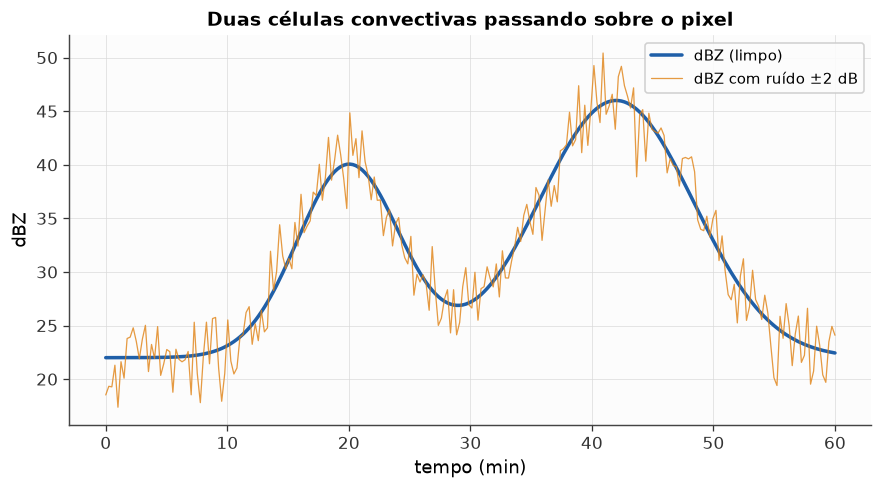

acumulado 1 h: convectiva   6.7 mm | M–P   6.3 mm (razão 1.06)
com ruído:     convectiva   7.4 mm | M–P   6.8 mm


In [8]:
rng = np.random.default_rng(8)
t = np.linspace(0, 60, 240)                    # min
dBZ_t = 22 + 18*np.exp(-((t-20)/6)**2) + 24*np.exp(-((t-42)/9)**2)

def acum(dBZ_serie):
    Z = 10**(dBZ_serie/10)
    Rc = (Z/300.0)**(1/1.4)
    Rmp = (Z/200.0)**(1/1.6)
    dt_h = (t[1]-t[0])/60
    return Rc.sum()*dt_h, Rmp.sum()*dt_h

a_c, a_mp = acum(dBZ_t)
ruido = rng.normal(0, 2.0, size=t.size)
a_cr, a_mpr = acum(dBZ_t + ruido)

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(t, dBZ_t, color=CORES['azul'], label='dBZ (limpo)')
ax.plot(t, dBZ_t + ruido, color=CORES['laranja'], lw=0.8, alpha=0.8,
        label='dBZ com ruído ±2 dB')
ax.set(xlabel='tempo (min)', ylabel='dBZ',
       title='Duas células convectivas passando sobre o pixel')
ax.legend()
plt.show()
print(f'acumulado 1 h: convectiva {a_c:5.1f} mm | M–P {a_mp:5.1f} mm '
      f'(razão {a_c/a_mp:.2f})')
print(f'com ruído:     convectiva {a_cr:5.1f} mm | M–P {a_mpr:5.1f} mm')

## N4 — Quebrando o dealias

In [9]:
Vmax = 12.0
x = np.linspace(0, 200, 600)

def testa(amp, escala_km=160):
    V = amp*np.sin(2*np.pi*x/escala_km)
    Vo = (V + Vmax) % (2*Vmax) - Vmax
    Vf = Vo.copy()
    for i in range(1, len(Vf)):
        while Vf[i] - Vf[i-1] > Vmax:  Vf[i] -= 2*Vmax
        while Vf[i] - Vf[i-1] < -Vmax: Vf[i] += 2*Vmax
    return np.max(np.abs(Vf - V))

print('amplitude | erro máx pós-dealias')
for amp in [20, 28, 40, 60, 90]:
    print(f'{amp:8.0f}  | {testa(amp):8.2f} m/s')
print('\nO método sobrevive a amplitudes grandes ENQUANTO o salto real entre')
print('pontos vizinhos ficar abaixo de Vmax; gradientes fortes (ou dados')
print('faltando) quebram a continuidade e o desdobramento propaga erro de 2Vmax.')
print(f'aqui: falha quando dV/dx·Δx > Vmax → amp ≳ {Vmax/(2*np.pi/160*(x[1]-x[0])):.0f} m/s')

amplitude | erro máx pós-dealias
      20  |     0.00 m/s
      28  |     0.00 m/s
      40  |     0.00 m/s
      60  |     0.00 m/s
      90  |     0.00 m/s

O método sobrevive a amplitudes grandes ENQUANTO o salto real entre
pontos vizinhos ficar abaixo de Vmax; gradientes fortes (ou dados
faltando) quebram a continuidade e o desdobramento propaga erro de 2Vmax.
aqui: falha quando dV/dx·Δx > Vmax → amp ≳ 915 m/s


---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*